In [ ]:
# import the necessery libreary
import pandas as pd
import numpy as np
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt
import os
from random import shuffle

In [ ]:
Train_dir="/content/train"
Test_dir="/content/test"

In [ ]:
IMG_SIZE=120
Model_name="NIKE_ADIDAS"

In [ ]:
def img_label(img):
  word_lab=img.split("_")[0]
  if word_lab == "NIKE":return [1,0]
  elif word_lab=='ADIDAS': return [0,1]

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
train_data=[]
for img in tqdm(os.listdir(Train_dir)):
  label=img_label(img)
  path=os.path.join(Train_dir,img)

  # PIL
  img=Image.open(path)
  img=img.convert('L')
  # img=img.resize((IMG_SIZE,IMG_SIZE),Image.ANTALIAS)
  img = img.resize((IMG_SIZE, IMG_SIZE), Image.Resampling.LANCZOS)

  train_data.append([np.array(img),np.array(label)])
shuffle(train_data)

100%|██████████| 100/100 [00:00<00:00, 227.97it/s]


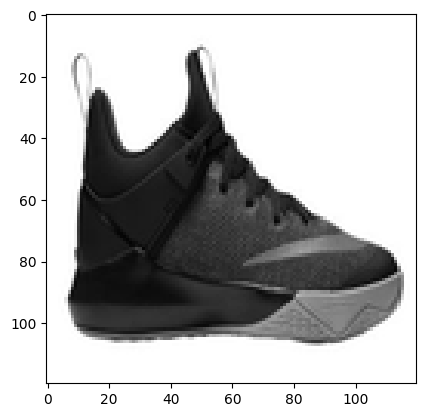

In [ ]:
# view thw image
plt.imshow(train_data[1][0],cmap='gist_gray')
plt.show()

In [ ]:
import keras
from keras.layers import Conv2D,MaxPooling2D
from keras.models import Sequential
from keras.layers import Dense,Dropout,Activation,Flatten


In [ ]:
# create the model or algorithm
model=Sequential()
model.add(Conv2D(32,(5,5),activation='relu',input_shape=(120,120,1)))
model.add(Conv2D(32,(5,5),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64,(5,5),activation='relu'))
model.add(Conv2D(64,(5,5),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64,(5,5),activation='relu'))
model.add(Conv2D(64,(5,5),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())

model.add(Dense(512,activation='relu'))
model.add(Dense(2,activation="softmax"))

model.compile(optimizer="adam",loss="categorical_crossentropy",metrics=["accuracy"])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# split the train and test data
x=np.array([i[0] for i  in train_data]).reshape(-1,IMG_SIZE,IMG_SIZE,1)
y=np.array([i[1] for i in train_data])

In [ ]:
model.fit(x,y,epochs=20)

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 18s 4s/step - accuracy: 0.5380 - loss: 87.2414
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.5667 - loss: 4.9411
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.5052 - loss: 0.8355
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.4995 - loss: 0.6737
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 20s 4s/step - accuracy: 0.5335 - loss: 0.6691
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.6498 - loss: 0.6192
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 15s 4s/step - accuracy: 0.7265 - loss: 0.6055
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 15s 4s/step - accuracy: 0.7102 - loss: 0.5387
Epoch 9/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 15s 3s/step - accuracy: 0.7726 - loss: 0.4419
Epoch 10/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.8708 - loss: 0.4032
Epoch 11/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 20s 4s/step - accuracy: 0.8583 - loss: 0.4059
Epoch 12/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.9283 - loss: 0.2254
Epoch 13/20


In [ ]:
# img=Image.open("/content/adidas_test.jpg")
img=Image.open("/content/niketest.jpg")
img=img.convert("L")
img=img.resize((IMG_SIZE,IMG_SIZE),Image.Resampling.LANCZOS)

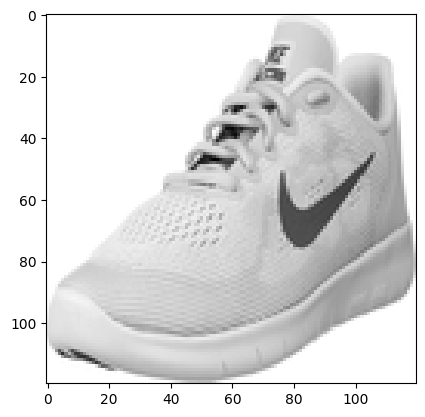

In [ ]:
# view thw image
plt.imshow(np.array(img),cmap='gist_gray')
plt.show()

In [ ]:
# Test with the help of predict module
model.predict(np.array(img).reshape(-1,IMG_SIZE,IMG_SIZE,1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step


array([[0.0248192 , 0.97518086]], dtype=float32)